In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Importing libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

dataset from https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [4]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Check Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


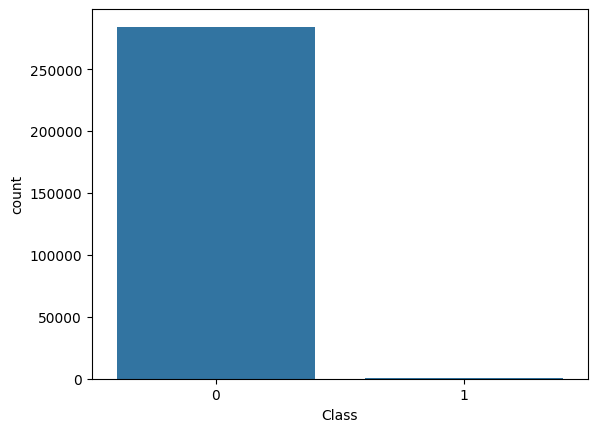

In [6]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.show()

In [7]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

Train Test split


In [8]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model traning


In [10]:
model = LogisticRegression()

model.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

prediction

In [11]:
y_pred = model.predict(X_test)

evaluating model

In [12]:
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_pred))

[[55885   979]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.90      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9403713335362283


In [13]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



Confusion Matrix

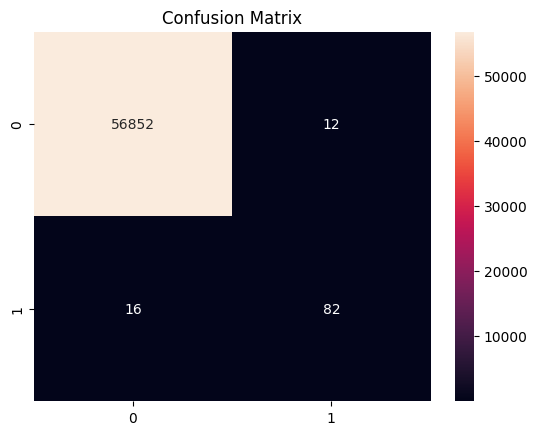

In [14]:
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.show()

 Receiver Operating Characteristic Curve.

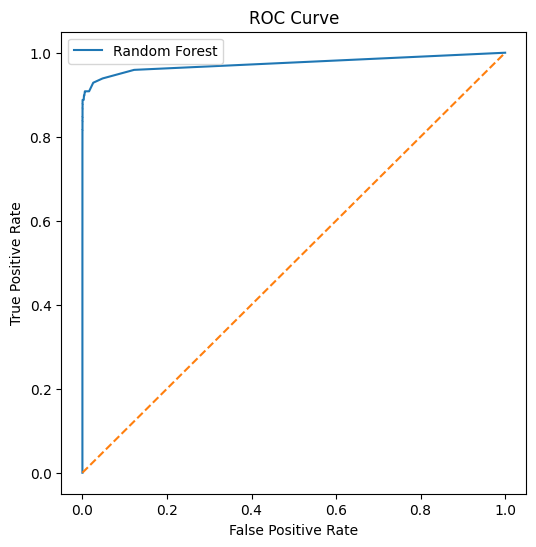

ROC-AUC Score: 0.974445203306421


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_probs))

features importances


In [16]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

   Feature  Importance
14     V14    0.218989
17     V17    0.131156
11     V11    0.110537
10     V10    0.102332
12     V12    0.091696
4       V4    0.091324
16     V16    0.044303
3       V3    0.037495
9       V9    0.030752
7       V7    0.027396


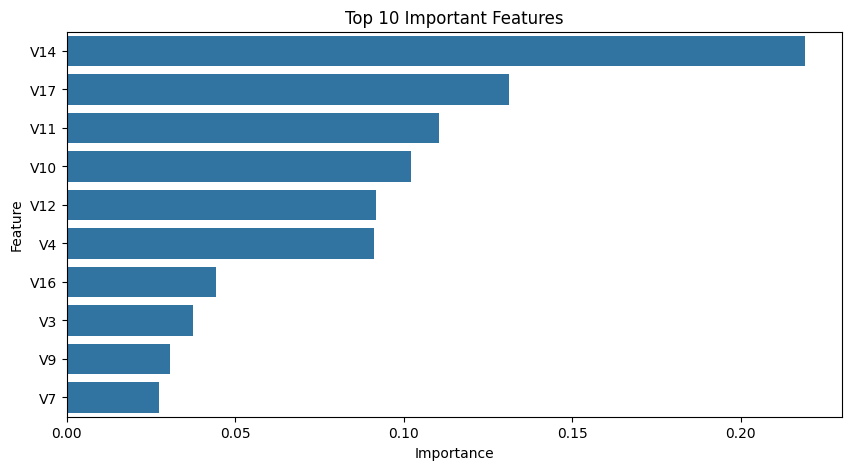

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

Fraud Prediction Function

In [18]:
def predict_transaction(transaction):

    transaction = np.array(transaction).reshape(1,-1)

    prediction = rf.predict(transaction)
    probability = rf.predict_proba(transaction)[0][1]

    if prediction == 1:
        print(" Fraudulent Transaction Detected")
    else:
        print(" Legitimate Transaction")

    print("Fraud Probability:", probability)

In [19]:
sample_transaction = X_test.iloc[0].values

predict_transaction(sample_transaction)

 Fraudulent Transaction Detected
Fraud Probability: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


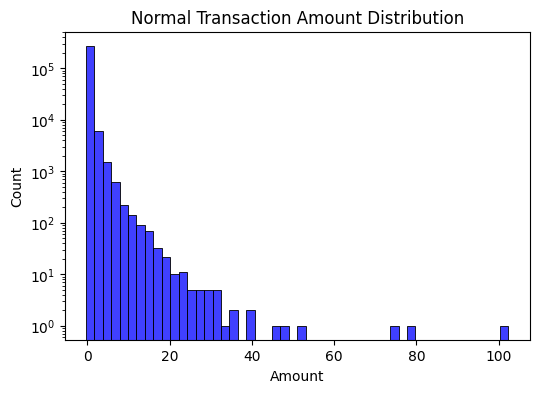

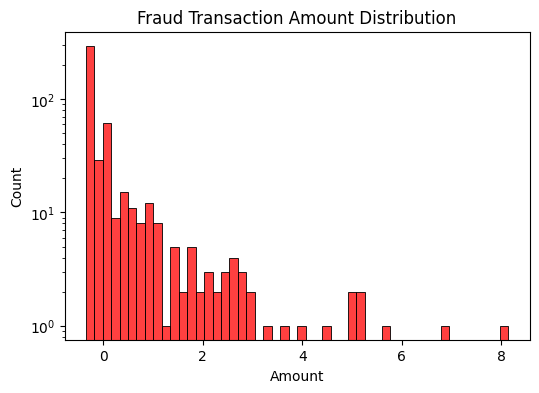

In [20]:
plt.figure(figsize=(6,4))

sns.histplot(df[df["Class"]==0]["Amount"], bins=50, color="blue")

plt.yscale("log")   # <-- add it here

plt.title("Normal Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.show()

plt.figure(figsize=(6,4))

sns.histplot(df[df["Class"]==1]["Amount"], bins=50, color="red")

plt.yscale("log")   # <-- same here

plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")

plt.show()

In [ ]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier

XGboost model

In [22]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

prediction

In [23]:
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
xgb_probs = xgb.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

ROC-AUC: 0.98845562774913


model comparision table


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": model.predict(X_test),
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([name, precision, recall, f1])

results_df = pd.DataFrame(results,
                          columns=["Model","Precision","Recall","F1 Score"])

print(results_df)

                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.082474  0.897959  0.151073
1        Random Forest   0.872340  0.836735  0.854167
2              XGBoost   0.768519  0.846939  0.805825


pickle

In [26]:
import pickle

pickle.dump(rf, open("fraud_model.pkl", "wb"))